# Donor Data Analysis

This notebook analyzes donor data from CSV files in the `data/` folder.

It includes:
- Section 1 — Top Donor Analysis
- Section 2 — Geographic Donor Analysis
- Section 3 — Time-Based Donation Analysis

Data files currently present in `data/`:
- donor_data.csv
- Riverkeeper_Donors.csv
- RiverKeeper_Donors_Unique_Locations.csv

(These files are still discovered and loaded dynamically in the next cell; the list above is just a human-readable snapshot.)

## Setup and Data Loading


In [ ]:
from __future__ import annotations

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")

# Use a repo-relative path 
DATA_DIR = Path("data")
if not DATA_DIR.exists():
    raise FileNotFoundError(
        "Could not find the 'data/' folder relative to the notebook working directory. "
        "Run this notebook from the repo root so Path('data') resolves correctly."
    )

csv_paths = sorted(DATA_DIR.glob("*.csv"))
print("Detected CSV files:")
for p in csv_paths:
    print(f"- {p.as_posix()}")

if not csv_paths:
    raise FileNotFoundError("No .csv files found in the 'data/' folder.")


def drop_unnamed_index_columns(df: pd.DataFrame) -> pd.DataFrame:
    unnamed = [c for c in df.columns if str(c).strip().lower().startswith("unnamed")]
    return df.drop(columns=unnamed) if unnamed else df


def parse_currency(series: pd.Series) -> pd.Series:
    """Parse strings like '$1,234.00 ' into floats. Non-parsable -> NaN."""
    s = series.astype(str)
    s = s.str.replace(r"[,$]", "", regex=True)
    s = s.str.replace(r"\(([^)]+)\)", r"-\1", regex=True)  # (123.45) -> -123.45
    s = s.str.replace(r"\s+", "", regex=True)
    s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan})
    return pd.to_numeric(s, errors="coerce")


US_STATE_NAME_TO_ABBR = {
    "alabama": "AL",
    "alaska": "AK",
    "arizona": "AZ",
    "arkansas": "AR",
    "california": "CA",
    "colorado": "CO",
    "connecticut": "CT",
    "delaware": "DE",
    "district of columbia": "DC",
    "florida": "FL",
    "georgia": "GA",
    "hawaii": "HI",
    "idaho": "ID",
    "illinois": "IL",
    "indiana": "IN",
    "iowa": "IA",
    "kansas": "KS",
    "kentucky": "KY",
    "louisiana": "LA",
    "maine": "ME",
    "maryland": "MD",
    "massachusetts": "MA",
    "michigan": "MI",
    "minnesota": "MN",
    "mississippi": "MS",
    "missouri": "MO",
    "montana": "MT",
    "nebraska": "NE",
    "nevada": "NV",
    "new hampshire": "NH",
    "new jersey": "NJ",
    "new mexico": "NM",
    "new york": "NY",
    "north carolina": "NC",
    "north dakota": "ND",
    "ohio": "OH",
    "oklahoma": "OK",
    "oregon": "OR",
    "pennsylvania": "PA",
    "rhode island": "RI",
    "south carolina": "SC",
    "south dakota": "SD",
    "tennessee": "TN",
    "texas": "TX",
    "utah": "UT",
    "vermont": "VT",
    "virginia": "VA",
    "washington": "WA",
    "west virginia": "WV",
    "wisconsin": "WI",
    "wyoming": "WY",
}


# --- Read + inspect each CSV BEFORE analysis (schema understanding) ---
raw_by_file: dict[str, pd.DataFrame] = {}

for path in csv_paths:
    df = pd.read_csv(path)
    df = drop_unnamed_index_columns(df)
    raw_by_file[path.name] = df

    print("\n" + "=" * 90)
    print(f"File: {path.name}")
    print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
    display(pd.DataFrame({"column": df.columns, "dtype": [str(t) for t in df.dtypes]}))
    display(df.head(5))


# --- Classify files by their columns (no hardcoded filenames) ---
# Donor summary type A: has Account ID + Total Gifts (All Time)
# Donor summary type B: has Account ID + Total Gifts Amount
# Location mapping: has Location + County (may include a state name in Location)

donor_a: pd.DataFrame | None = None
donor_b: pd.DataFrame | None = None
locations: pd.DataFrame | None = None

for _, df in raw_by_file.items():
    cols = set(map(str, df.columns))
    if {"Account ID", "Total Gifts (All Time)"}.issubset(cols):
        donor_a = df.copy()
    elif {"Account ID", "Total Gifts Amount"}.issubset(cols):
        donor_b = df.copy()
    elif {"Location", "County"}.issubset(cols):
        locations = df.copy()

if donor_a is None and donor_b is None:
    raise ValueError(
        "Could not find a donor CSV with donation totals. "
        "Expected columns like 'Account ID' and 'Total Gifts (All Time)' or 'Total Gifts Amount'."
    )


def standardize_donor_df(df: pd.DataFrame, amount_col: str) -> pd.DataFrame:
    out = drop_unnamed_index_columns(df.copy())

    # Normalize column names
    out = out.rename(
        columns={
            "Account ID": "Donor ID",
            "Last Gift Date": "Donation Date",
            amount_col: "Donation Amount",
        }
    )

    # Trim key strings
    for c in ["Donor ID", "City", "State", "Country"]:
        if c in out.columns:
            out[c] = out[c].astype(str).str.strip().replace({"": np.nan, "nan": np.nan})

    # Parse currency + date
    if "Donation Amount" in out.columns:
        out["Donation Amount"] = parse_currency(out["Donation Amount"])
    else:
        out["Donation Amount"] = np.nan

    out["Donation Date"] = pd.to_datetime(out.get("Donation Date"), errors="coerce")

    keep = [c for c in ["Donor ID", "City", "State", "Country", "Donation Amount", "Donation Date"] if c in out.columns]
    out = out[keep]
    out = out.dropna(subset=["Donor ID"]).copy()
    return out


donor_frames: list[pd.DataFrame] = []
if donor_a is not None:
    donor_frames.append(standardize_donor_df(donor_a, amount_col="Total Gifts (All Time)"))
if donor_b is not None:
    donor_frames.append(standardize_donor_df(donor_b, amount_col="Total Gifts Amount"))

donors_stacked = pd.concat(donor_frames, ignore_index=True)


def mode_non_null(s: pd.Series):
    s = s.dropna()
    if s.empty:
        return np.nan
    return s.value_counts().index[0]


# Build a donor-level master table without double-counting totals across sources:
# - Donation Amount: take MAX across sources (safer than SUM for "all time" totals)
# - Donation Date: take latest available date
# - City/State/Country: take the most common non-null value

donor_master = (
    donors_stacked.groupby("Donor ID", as_index=False)
    .agg(
        **{
            "Donation Amount": ("Donation Amount", "max"),
            "Donation Date": ("Donation Date", "max"),
            "State": ("State", mode_non_null),
            "City": ("City", mode_non_null),
            "Country": ("Country", mode_non_null),
        }
    )
)


# Optional: attach County using the locations file (best-effort)
if locations is not None:
    loc = drop_unnamed_index_columns(locations.copy())

    # Extract state name from 'Location' like "City, New York" -> "New York" -> "NY"
    if "Location" in loc.columns:
        loc["_state_name"] = loc["Location"].astype(str).str.split(",").str[-1].str.strip().str.lower()
        loc["State"] = loc["_state_name"].map(US_STATE_NAME_TO_ABBR)

    if "City" in loc.columns:
        loc["City"] = loc["City"].astype(str).str.strip()

    county_map = (
        loc.dropna(subset=["City", "State", "County"])
        .assign(
            _city_key=lambda d: d["City"].str.lower().str.strip(),
            _state_key=lambda d: d["State"].astype(str).str.upper().str.strip(),
        )
        .groupby(["_city_key", "_state_key"], as_index=False)
        .agg(County=("County", mode_non_null))
    )

    donor_master = donor_master.assign(
        _city_key=lambda d: d["City"].astype(str).str.lower().str.strip(),
        _state_key=lambda d: d["State"].astype(str).str.upper().str.strip(),
    )

    donor_master = donor_master.merge(county_map, on=["_city_key", "_state_key"], how="left")
    donor_master = donor_master.drop(columns=["_city_key", "_state_key"], errors="ignore")


print("\nDonor master (cleaned) preview:")
display(donor_master.head(10))

print("\nDonor master schema:")
display(pd.DataFrame({"column": donor_master.columns, "dtype": [str(t) for t in donor_master.dtypes]}))

print(f"\nUnique donors: {donor_master['Donor ID'].nunique():,}")


Detected CSV files:
- data/donor_data.csv
- data/Riverkeeper_Donors.csv
- data/RiverKeeper_Donors_Unique_Locations.csv

File: donor_data.csv
Rows: 8,297 | Columns: 9


,column,dtype
0,Account ID,object
1,City,object
2,State,object
3,BFPO No,object
4,Postcode,object
5,Country,object
6,Total Gifts (All Time),object
7,Last Gift Date,object
8,Number of Gifts Past 18 Months,float64


,Account ID,City,State,BFPO No,Postcode,Country,Total Gifts (All Time),Last Gift Date,Number of Gifts Past 18 Months
0,001PY00000cQeQaYAK,North Salem,NY,NaN,NaN,United States,"$9,750.00",11/27/2024,1.0
1,001PY00000egj2hYAA,Newburgh,NY,NaN,NaN,United States,"$1,500.00",3/11/2024,0.0
2,001PY00000egj2sYAA,Valley Cottage,NY,NaN,NaN,United States,"$79,400.00",11/18/2024,1.0
3,001PY00000egj2tYAA,New York,NY,NaN,NaN,United States,"$135,000.00",11/26/2024,1.0
4,001PY00000egj2wYAA,Carrollton,TX,NaN,NaN,United States,"$2,130.00",3/1/2023,0.0



File: Riverkeeper_Donors.csv
Rows: 8,196 | Columns: 8


,column,dtype
0,Account ID,object
1,City,object
2,State,object
3,BFPO No,object
4,Postcode,object
5,Country,object
6,Total Gifts Amount,object
7,Last Gift Date,object


...


Donor master (cleaned) preview:


,Donor ID,Donation Amount,Donation Date,State,City,Country,County
0,001PY00000cQeQaYAK,9750.00,2024-11-27,NY,North Salem,United States,Westchester
1,001PY00000egj2hYAA,1500.00,2024-03-11,NY,Newburgh,United States,NaN
2,001PY00000egj2sYAA,79400.00,2024-11-18,NY,Valley Cottage,United States,Rockland County
3,001PY00000egj2tYAA,135000.00,2024-11-26,NY,New York,United States,
4,001PY00000egj2wYAA,2130.00,2023-03-01,TX,Carrollton,United States,Dallas
5,001PY00000egj2yYAA,500.00,2022-08-08,NY,New York,United States,
6,001PY00000egj33YAA,500.00,2023-12-11,OH,Hudson,United States,Summit
7,001PY00000egzubYAA,914700.00,2025-06-26,NY,New York,United States,
8,001PY00000ehC0XYAU,686.00,2021-06-30,NaN,NaN,United States,NaN
9,001PY00000ehgwnYAA,324.07,2022-06-15,NY,New York,United States,



Donor master schema:


,column,dtype
0,Donor ID,object
1,Donation Amount,float64
2,Donation Date,datetime64[ns]
3,State,object
4,City,object
5,Country,object
6,County,object



Unique donors: 8,297


## Section 1 — Top Donor Analysis

Aggregate total donations per unique donor ID, identify the top 5% of donors by total donation amount, and visualize concentration among top donors.

Total donors with a donation total: 8,297
Top 5% donor count: 415
Overall total donations (from available totals): $51,998,061.92


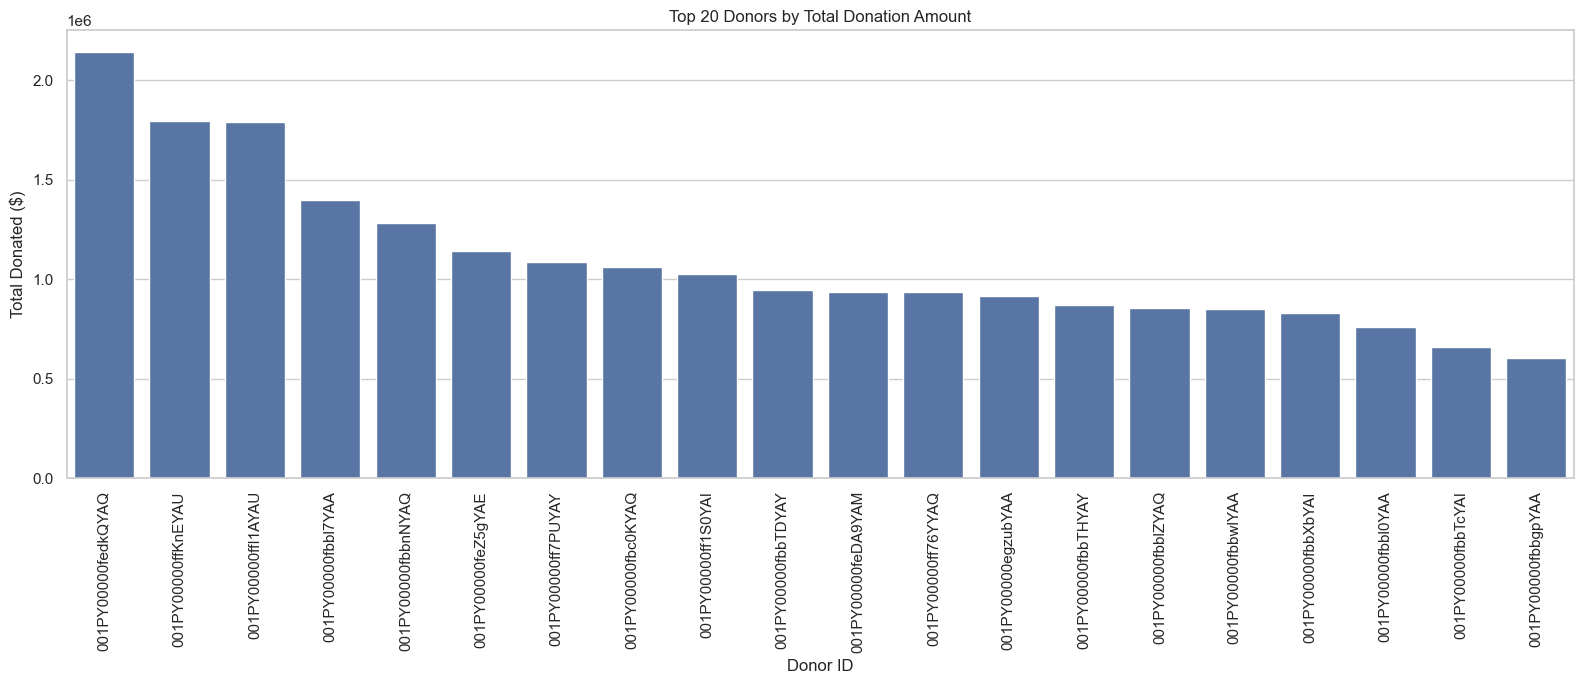

In [3]:
# Use the cleaned donor-level table from Setup
analysis_df = donor_master.copy()
analysis_df = analysis_df.dropna(subset=["Donor ID", "Donation Amount"]).copy()

# Aggregate total donated per donor (already donor-level, but this keeps logic robust)
donor_totals = (
    analysis_df.groupby("Donor ID", as_index=False)["Donation Amount"]
    .sum()
    .sort_values("Donation Amount", ascending=False)
)

total_donations = donor_totals["Donation Amount"].sum()

# Top 5% donors by count (ceil so we always include at least 1 donor)
top_n = max(1, math.ceil(0.05 * len(donor_totals)))
top_5 = donor_totals.head(top_n).copy()

print(f"Total donors with a donation total: {len(donor_totals):,}")
print(f"Top 5% donor count: {top_n:,}")
print(f"Overall total donations (from available totals): ${total_donations:,.2f}")

# (1) Bar chart: top 20 individual donors
plt.figure(figsize=(16, 7))
top_20 = donor_totals.head(20)
sns.barplot(data=top_20, x="Donor ID", y="Donation Amount")
plt.xlabel("Donor ID")
plt.ylabel("Total Donated ($)")
plt.title("Top 20 Donors by Total Donation Amount")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Observations (Top 20 donors)
The distribution is typically very top-heavy: a small number of donors contribute disproportionately large totals compared to the rest.

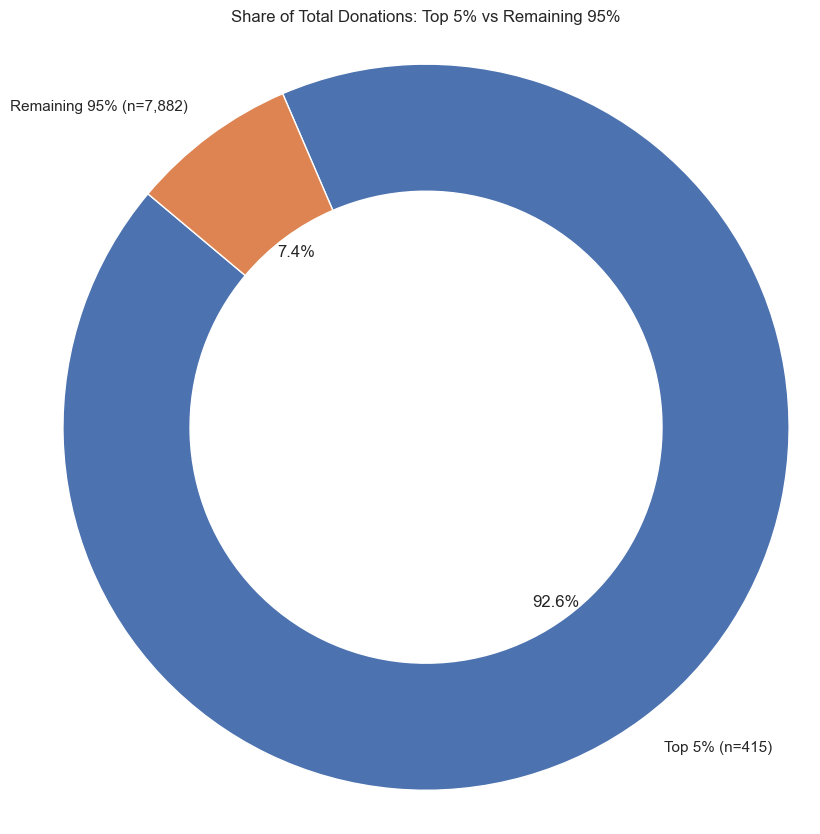

,Donor ID,Total Donated,% of Overall Total
1216,001PY00000fedkQYAQ,2144100.00,4.123423
5996,001PY00000ffKnEYAU,1794553.48,3.451193
5517,001PY00000ffI1AYAU,1790200.00,3.442821
256,001PY00000fbbl7YAA,1400000.00,2.692408
259,001PY00000fbbnNYAQ,1285000.00,2.471246
...,...,...,...
4004,001PY00000ffCMxYAM,6340.00,0.012193
705,001PY00000feFDyYAM,6293.78,0.012104
3554,001PY00000ffAOKYA2,6200.00,0.011924
1976,001PY00000ff1yTYAQ,6200.00,0.011924


In [4]:
# (2) Donut chart: share of all donations from top 5% vs remaining 95%
top_5_sum = top_5["Donation Amount"].sum()
remaining_sum = total_donations - top_5_sum

labels = [f"Top 5% (n={len(top_5):,})", f"Remaining 95% (n={len(donor_totals) - len(top_5):,})"]
values = [top_5_sum, remaining_sum]

plt.figure(figsize=(8.5, 8.5))
plt.pie(
    values,
    labels=labels,
    autopct=lambda p: f"{p:.1f}%",
    startangle=140,
    wedgeprops=dict(width=0.35),
)
plt.title("Share of Total Donations: Top 5% vs Remaining 95%")
plt.axis("equal")
plt.tight_layout()
plt.show()

# Summary table: top 5% donors
summary = top_5.rename(columns={"Donation Amount": "Total Donated"}).copy()
summary["% of Overall Total"] = (summary["Total Donated"] / total_donations) * 100

# Keep exactly the requested columns
summary = summary[["Donor ID", "Total Donated", "% of Overall Total"]]

display(summary)

### Observations (Top 5% concentration)
The donut chart quantifies concentration risk: if the top slice is large, fundraising totals may depend heavily on retaining a small set of high-value donors.

## Section 2 — Geographic Donor Analysis

Summarize donors and donation totals by state, then drill down to county-level patterns (top 10 states by donor count for readability).

,Donor_Count,Total_Donations
State,,
NY,6400,40068831.78
NJ,374,1511624.70
CT,120,1880700.27
CA,78,1473650.91
MA,72,498476.06
FL,67,130811.71
PA,51,928622.17
VA,30,149803.98
GA,29,26822.00


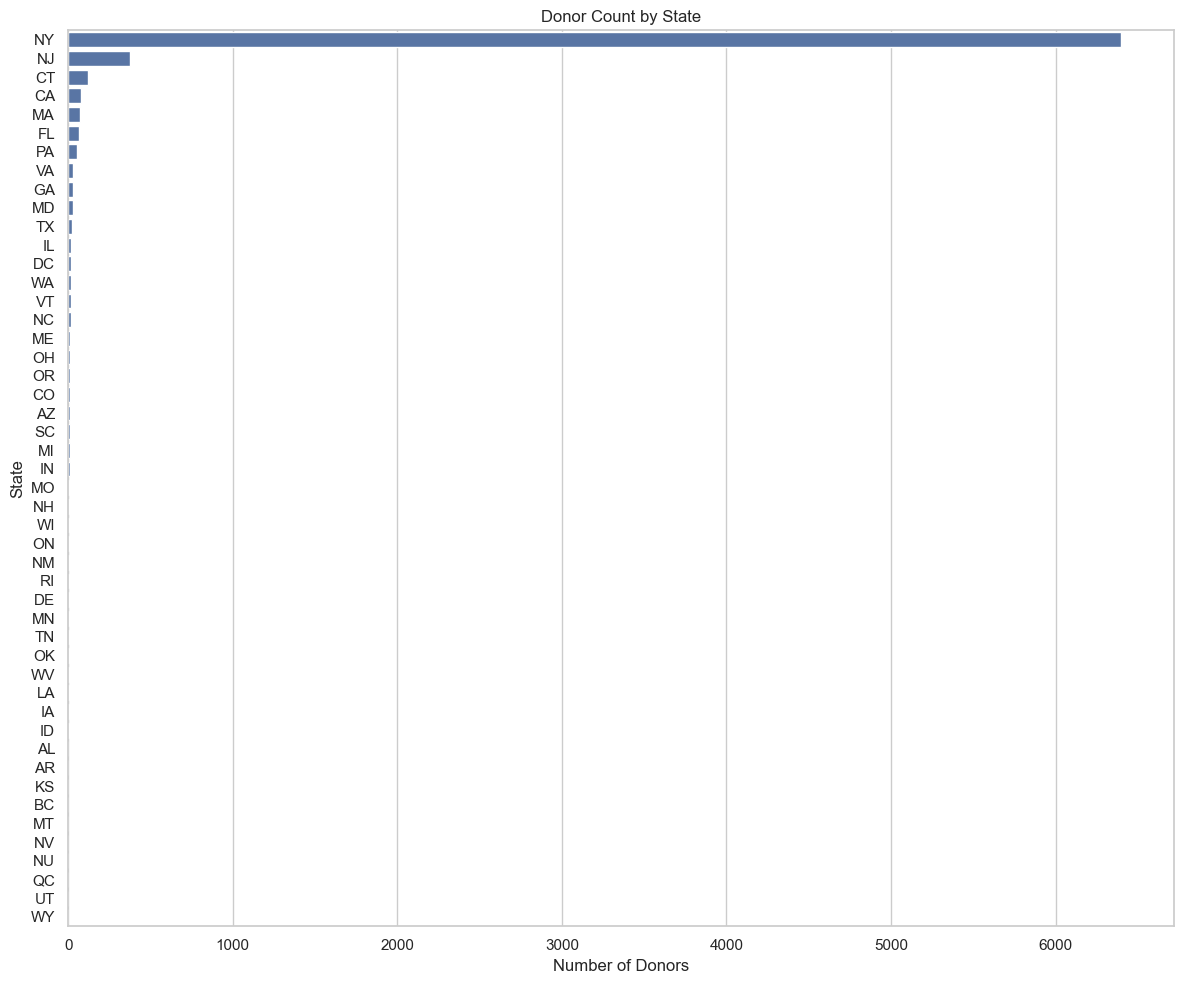

In [5]:
geo_df = donor_master.dropna(subset=["State"]).copy()

# State summary table: donor count + total donations
state_summary = (
    geo_df.groupby("State")
    .agg(
        Donor_Count=("Donor ID", "nunique"),
        Total_Donations=("Donation Amount", "sum"),
    )
    .sort_values("Donor_Count", ascending=False)
)

display(state_summary)

# Horizontal bar chart: donor count by state
plt.figure(figsize=(12, 10))
sns.barplot(x=state_summary["Donor_Count"], y=state_summary.index)
plt.xlabel("Number of Donors")
plt.ylabel("State")
plt.title("Donor Count by State")
plt.tight_layout()
plt.show()

### Observations (State distribution)
States with the most donors are natural candidates for targeted outreach. Compare donor counts to total donations to see whether a state has many small donors or fewer larger donors.


--------------------------------------------------------------------------------
State: NY (showing top 20 counties by donor count)


,Donor_Count,Total_Donations
County,,
Unknown,3181,14574495.22
,1229,17802804.30
Westchester,762,2222539.42
Dutchess,236,429645.17
Rockland,184,502978.24
Ulster,183,1727988.10
Nassau,79,47808.10
Orange,69,37106.80
Albany,68,1816761.59


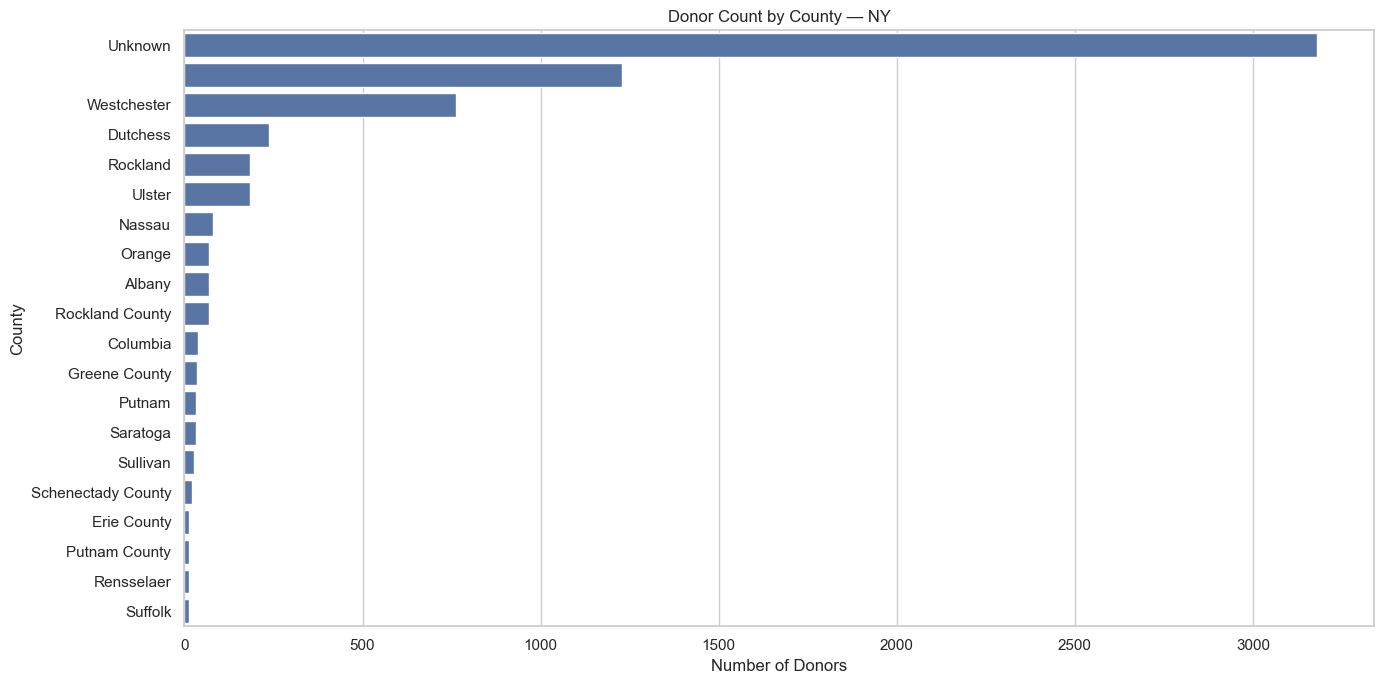


--------------------------------------------------------------------------------
State: NJ (showing top 20 counties by donor count)


,Donor_Count,Total_Donations
County,,
Bergen,110,97344.66
Unknown,67,294807.26
Hudson,51,22151.87
Essex,47,107230.43
Morris,17,45905.63
Mercer,14,37216.57
Union,14,879632.70
Monmouth,11,14967.64
Middlesex,10,3240.00


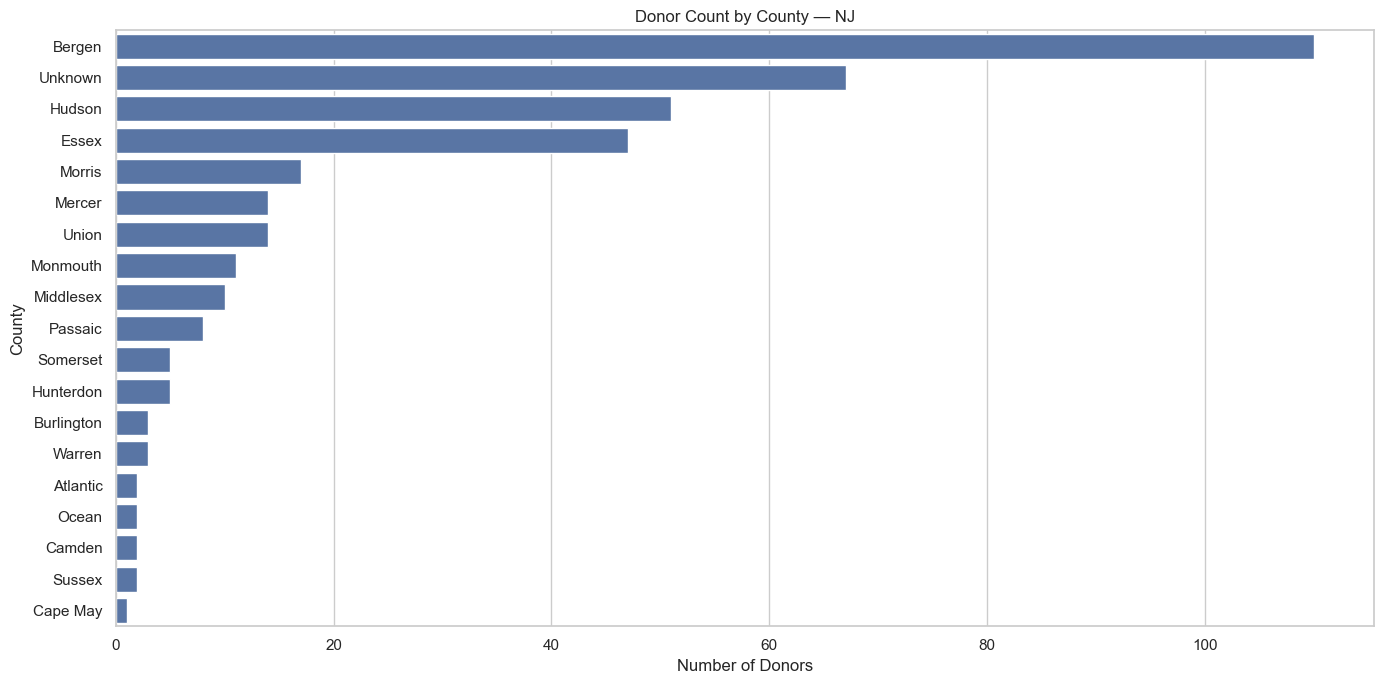


--------------------------------------------------------------------------------
State: CT (showing top 20 counties by donor count)


,Donor_Count,Total_Donations
County,,
Western Connecticut Planning Region,56,272632.95
Unknown,21,1021788.28
Greater Bridgeport Planning Region,19,575639.55
Capitol Planning Region,9,2215.00
South Central Connecticut Planning Region,8,5120.00
Northwest Hills Planning Region,4,3014.49
Naugatuck Valley Planning Region,3,290.00


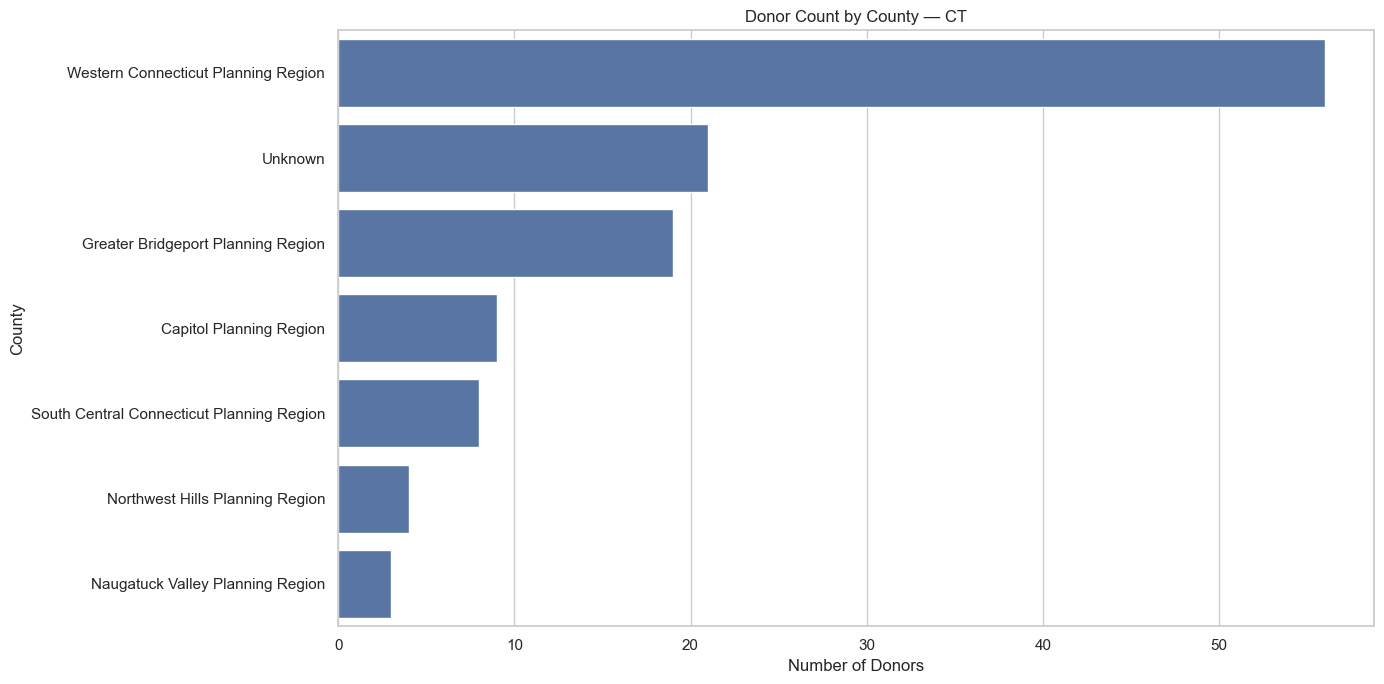


--------------------------------------------------------------------------------
State: CA (showing top 20 counties by donor count)


,Donor_Count,Total_Donations
County,,
Los Angeles,19,34160.00
Unknown,16,1002968.56
,10,113474.22
Alameda County,4,14066.63
Contra Costa,3,650.00
Ventura,3,177172.50
Marin,3,25550.00
San Diego,3,120.00
Santa Clara,2,309.00


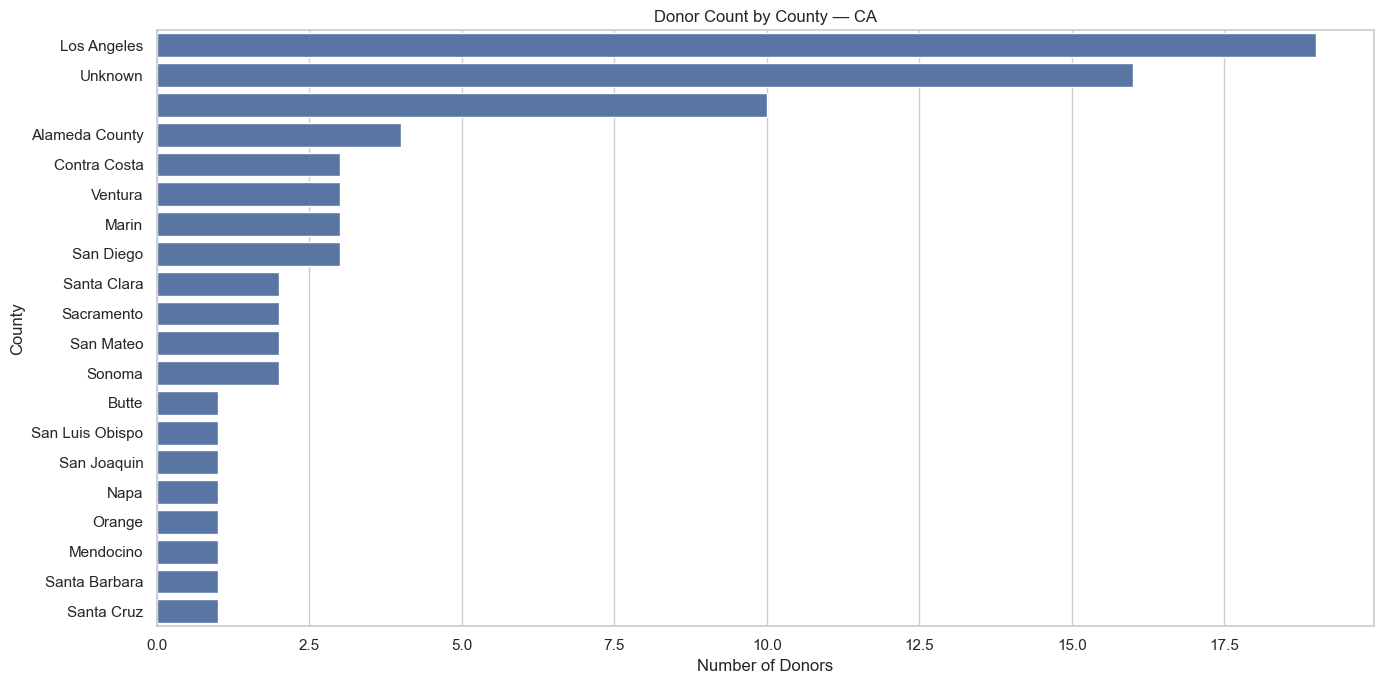


--------------------------------------------------------------------------------
State: MA (showing top 20 counties by donor count)


,Donor_Count,Total_Donations
County,,
Unknown,72,498476.06


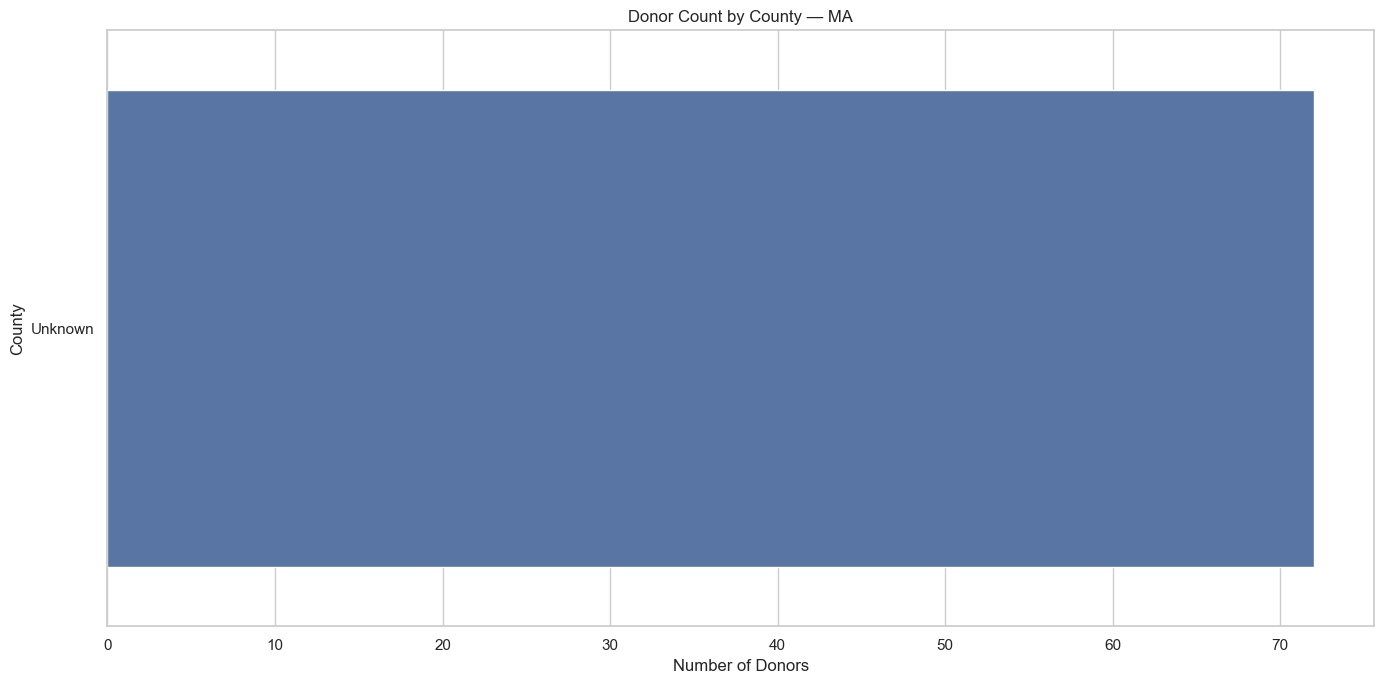


--------------------------------------------------------------------------------
State: FL (showing top 20 counties by donor count)


,Donor_Count,Total_Donations
County,,
Unknown,9,3953.41
Miami-Dade,8,91333.00
Pinellas,6,1937.49
Lee,5,1790.50
Sarasota,5,2675.50
Palm Beach,5,12160.00
Orange County,4,125.88
Duval,3,136.00
Saint Lucie,3,11850.50


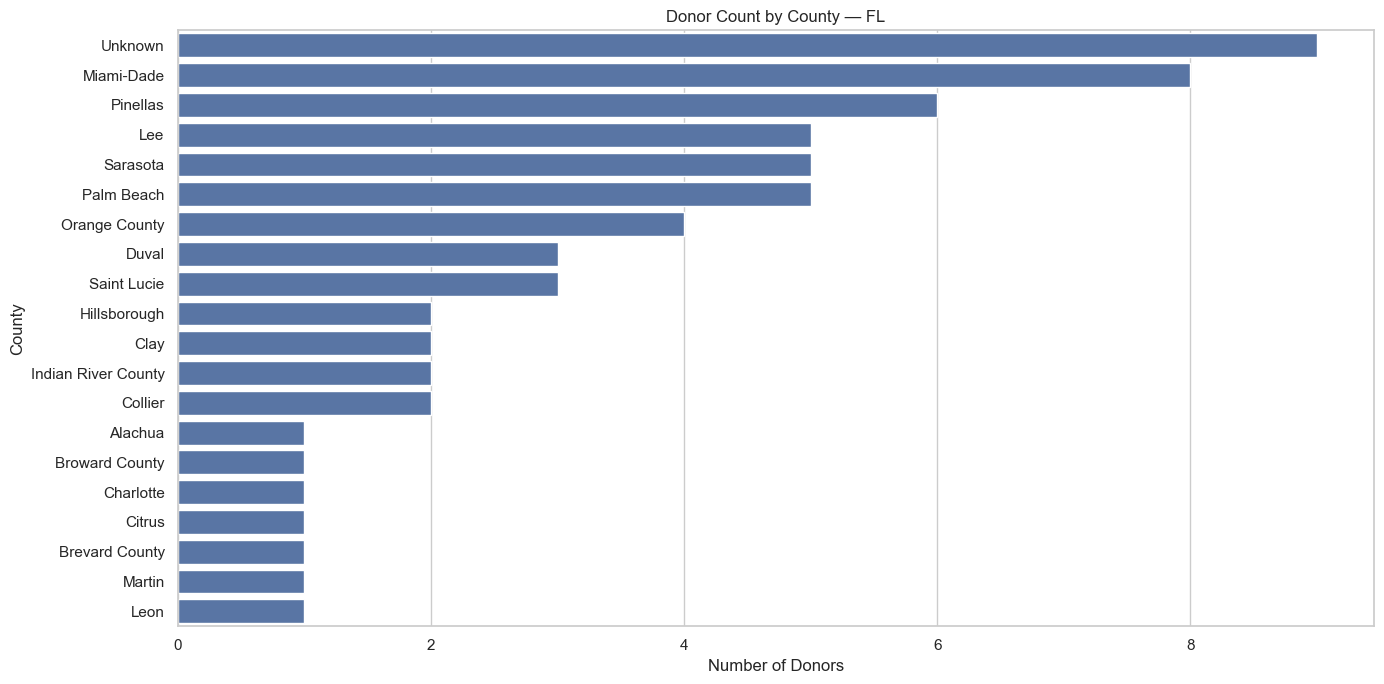


--------------------------------------------------------------------------------
State: PA (showing top 20 counties by donor count)


,Donor_Count,Total_Donations
County,,
Unknown,21,252395.20
Philadelphia,12,664975.97
Chester,3,985.00
Allegheny,2,510.00
Lehigh,2,60.00
Lancaster,1,5710.00
Butler County,1,70.00
Adams,1,974.00
Monroe,1,447.00


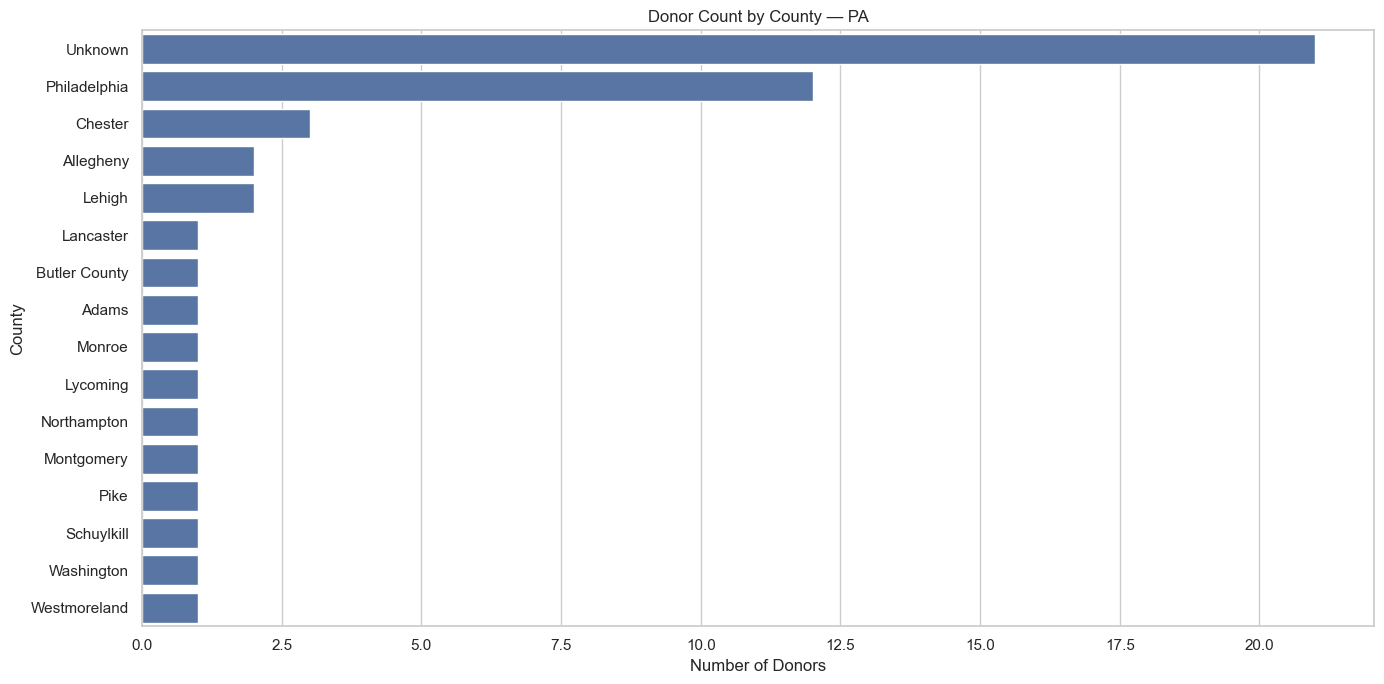


--------------------------------------------------------------------------------
State: VA (showing top 20 counties by donor count)


,Donor_Count,Total_Donations
County,,
,17,141048.98
Unknown,5,1180.00
Fairfax,3,7355.00
Chesterfield,1,15.00
Hanover,1,45.00
Loudoun,1,10.00
Prince William,1,100.00
Westchester,1,50.00


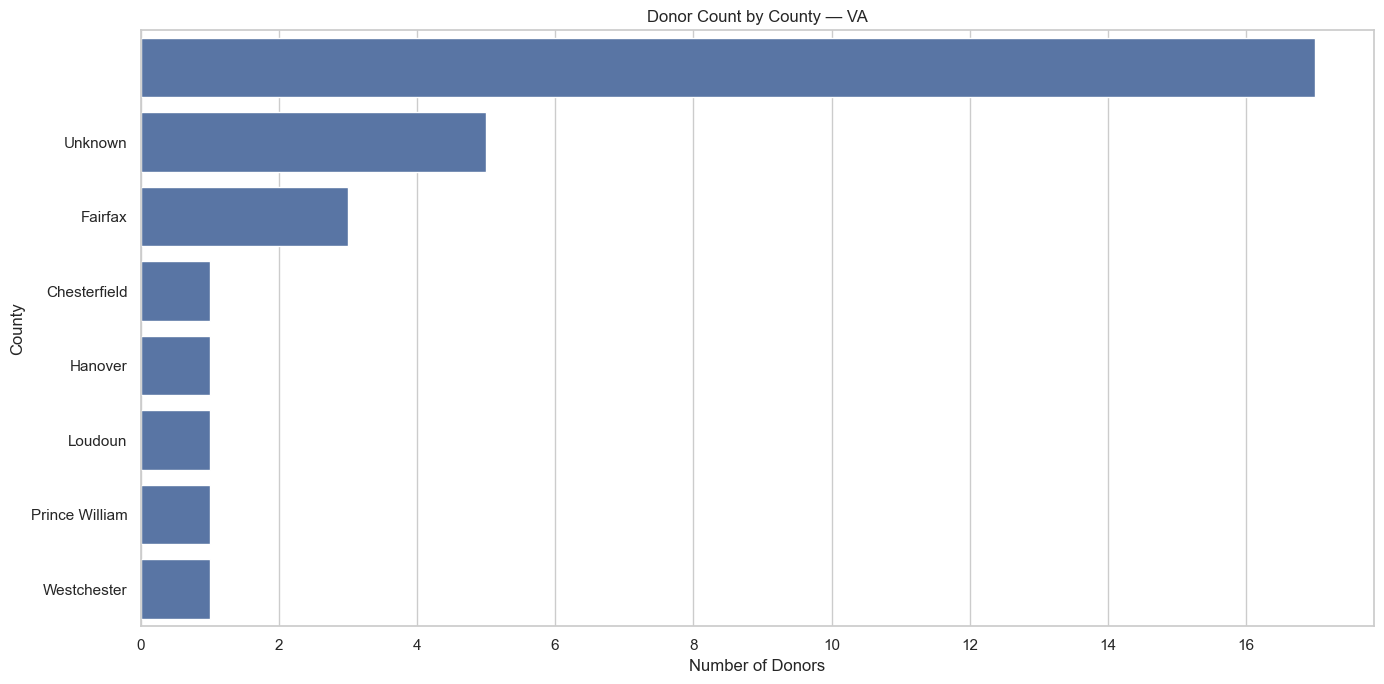


--------------------------------------------------------------------------------
State: GA (showing top 20 counties by donor count)


,Donor_Count,Total_Donations
County,,
Fulton,15,22417.5
Unknown,7,1035.0
DeKalb,2,53.0
Cobb,2,66.5
Gwinnett,2,2000.0
McIntosh,1,1250.0


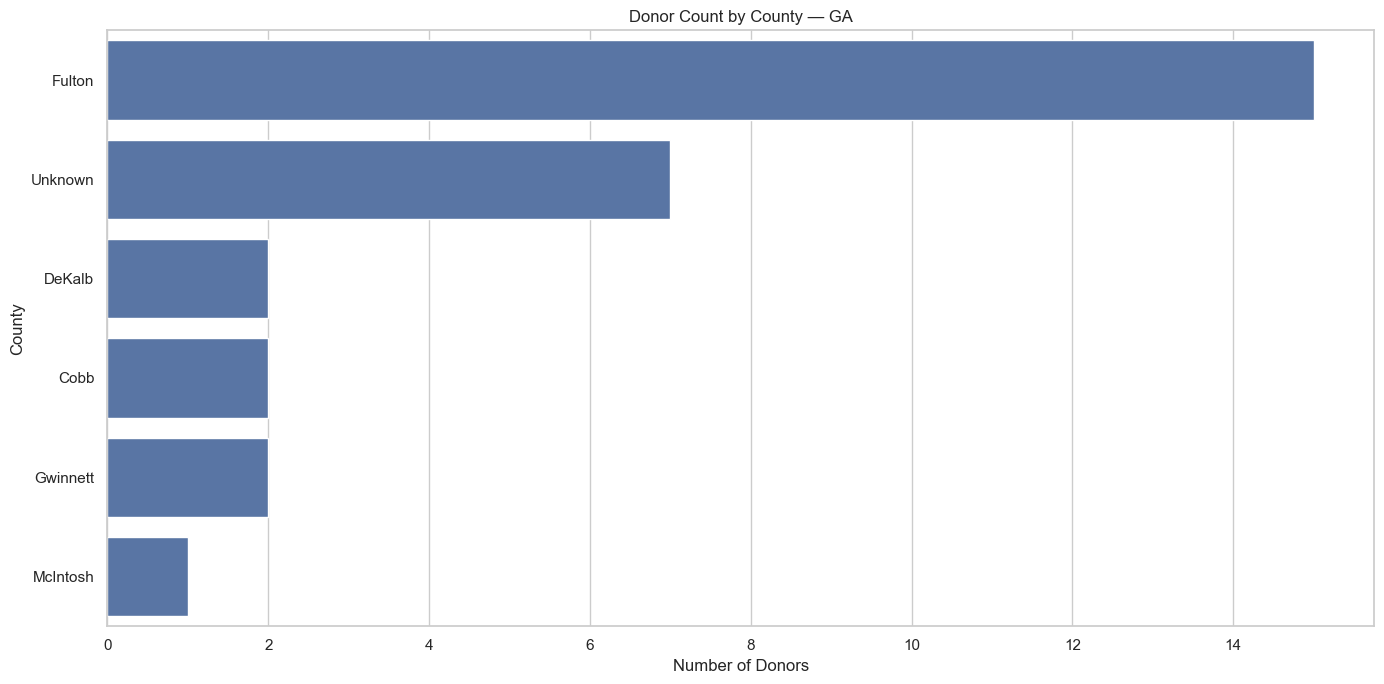


--------------------------------------------------------------------------------
State: MD (showing top 20 counties by donor count)


,Donor_Count,Total_Donations
County,,
Montgomery,14,431315.54
Unknown,5,2133.00
Anne Arundel,2,185.44
,1,1000.00
Howard,1,40.00
Caroline,1,366.00
Prince George's,1,9557.02
Talbot,1,42500.00


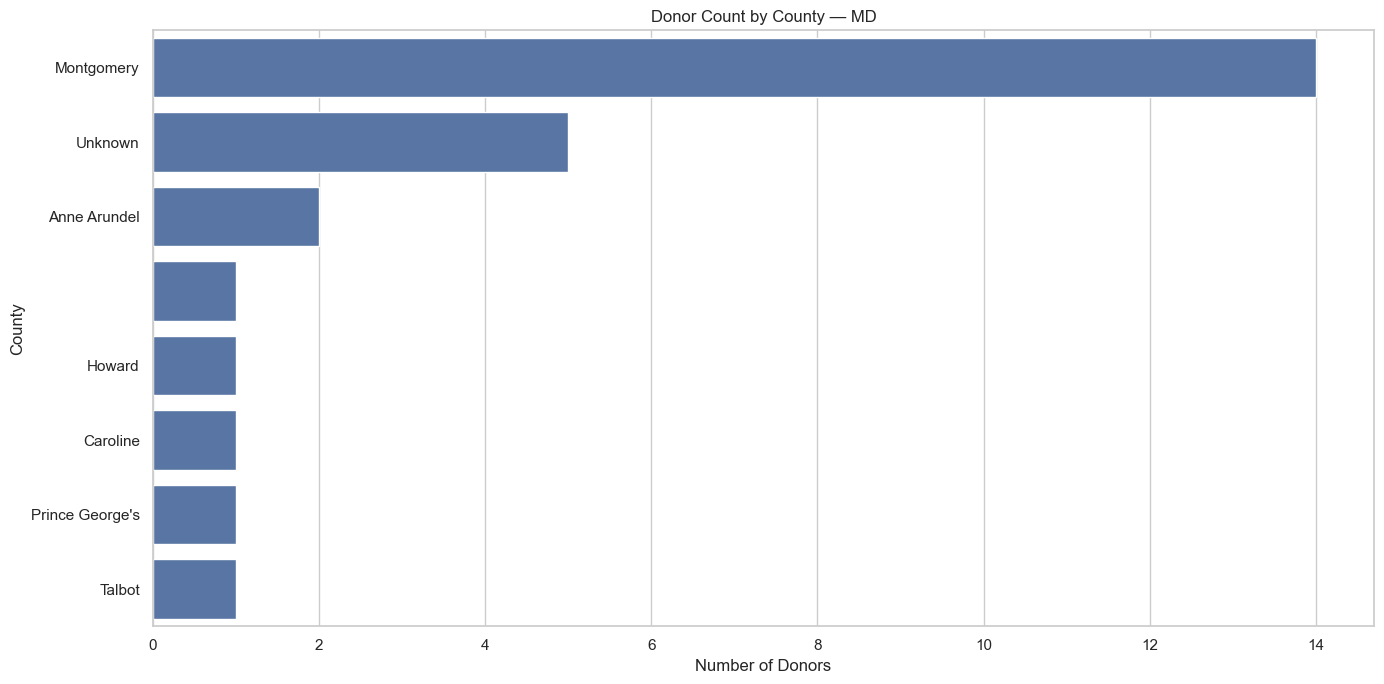

In [6]:
# Drill-down: counties for top 10 states by donor count
# County may be missing if it cannot be inferred from the location mapping file.

TOP_STATES = 10
TOP_COUNTIES_PER_STATE = 20  # keep charts readable

if "County" not in geo_df.columns:
    print("No county column is available in donor_master. (County mapping file may be missing.)")
else:
    top_states = state_summary.head(TOP_STATES).index.tolist()

    for st in top_states:
        st_df = geo_df[geo_df["State"] == st].copy()
        st_df["County"] = st_df["County"].fillna("Unknown")

        county_summary = (
            st_df.groupby("County")
            .agg(
                Donor_Count=("Donor ID", "nunique"),
                Total_Donations=("Donation Amount", "sum"),
            )
            .sort_values("Donor_Count", ascending=False)
        )

        print("\n" + "-" * 80)
        print(f"State: {st} (showing top {TOP_COUNTIES_PER_STATE} counties by donor count)")
        display(county_summary.head(TOP_COUNTIES_PER_STATE))

        plot_df = county_summary.head(TOP_COUNTIES_PER_STATE).reset_index()
        plt.figure(figsize=(14, 7))
        sns.barplot(data=plot_df, x="Donor_Count", y="County")
        plt.xlabel("Number of Donors")
        plt.ylabel("County")
        plt.title(f"Donor Count by County — {st}")
        plt.tight_layout()
        plt.show()

### Observations (County drill-down)
The county breakdown within high-donor states can reveal local clusters of support. Counties labeled “Unknown” indicate donors whose county could not be inferred from the available location mapping.

## Section 3 — Time-Based Donation Analysis

Parse the available donation date field as a datetime and analyze monthly donation trends overall and by state.

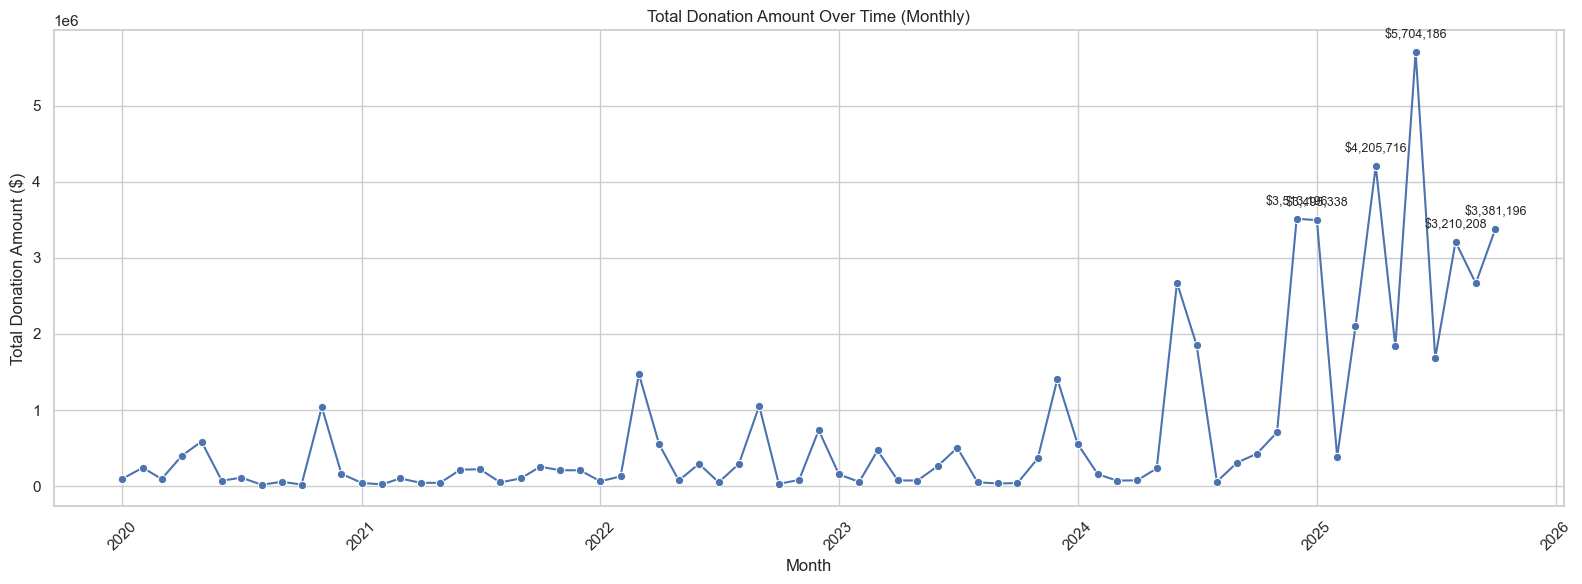

Spike threshold used: $3,091,190.79


,Month,Donation Amount
59,2024-12-01,3513196.01
60,2025-01-01,3495337.63
63,2025-04-01,4205716.31
65,2025-06-01,5704185.76
67,2025-08-01,3210207.93
69,2025-10-01,3381196.39


In [7]:
time_df = donor_master.dropna(subset=["Donation Date", "Donation Amount"]).copy()

# Aggregate by month (chronological)
time_df["Month"] = time_df["Donation Date"].dt.to_period("M").dt.to_timestamp()
monthly_total = time_df.groupby("Month", as_index=False)["Donation Amount"].sum().sort_values("Month")

plt.figure(figsize=(16, 6))
sns.lineplot(data=monthly_total, x="Month", y="Donation Amount", marker="o")
plt.xlabel("Month")
plt.ylabel("Total Donation Amount ($)")
plt.title("Total Donation Amount Over Time (Monthly)")
plt.xticks(rotation=45)
plt.grid(True)

# Annotate notable spikes: values > mean + 2*std
threshold = monthly_total["Donation Amount"].mean() + 2 * monthly_total["Donation Amount"].std(ddof=0)
spikes = monthly_total[monthly_total["Donation Amount"] > threshold]
for _, r in spikes.iterrows():
    plt.annotate(
        f"${r['Donation Amount']:,.0f}",
        (r["Month"], r["Donation Amount"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

print(f"Spike threshold used: ${threshold:,.2f}")
display(spikes)

### Observations (Overall monthly trend)
Spikes can indicate campaign effects or major gifts. Because the available date field may represent “last gift date” (not necessarily each gift), treat this as a trend proxy rather than a complete transaction-level time series.

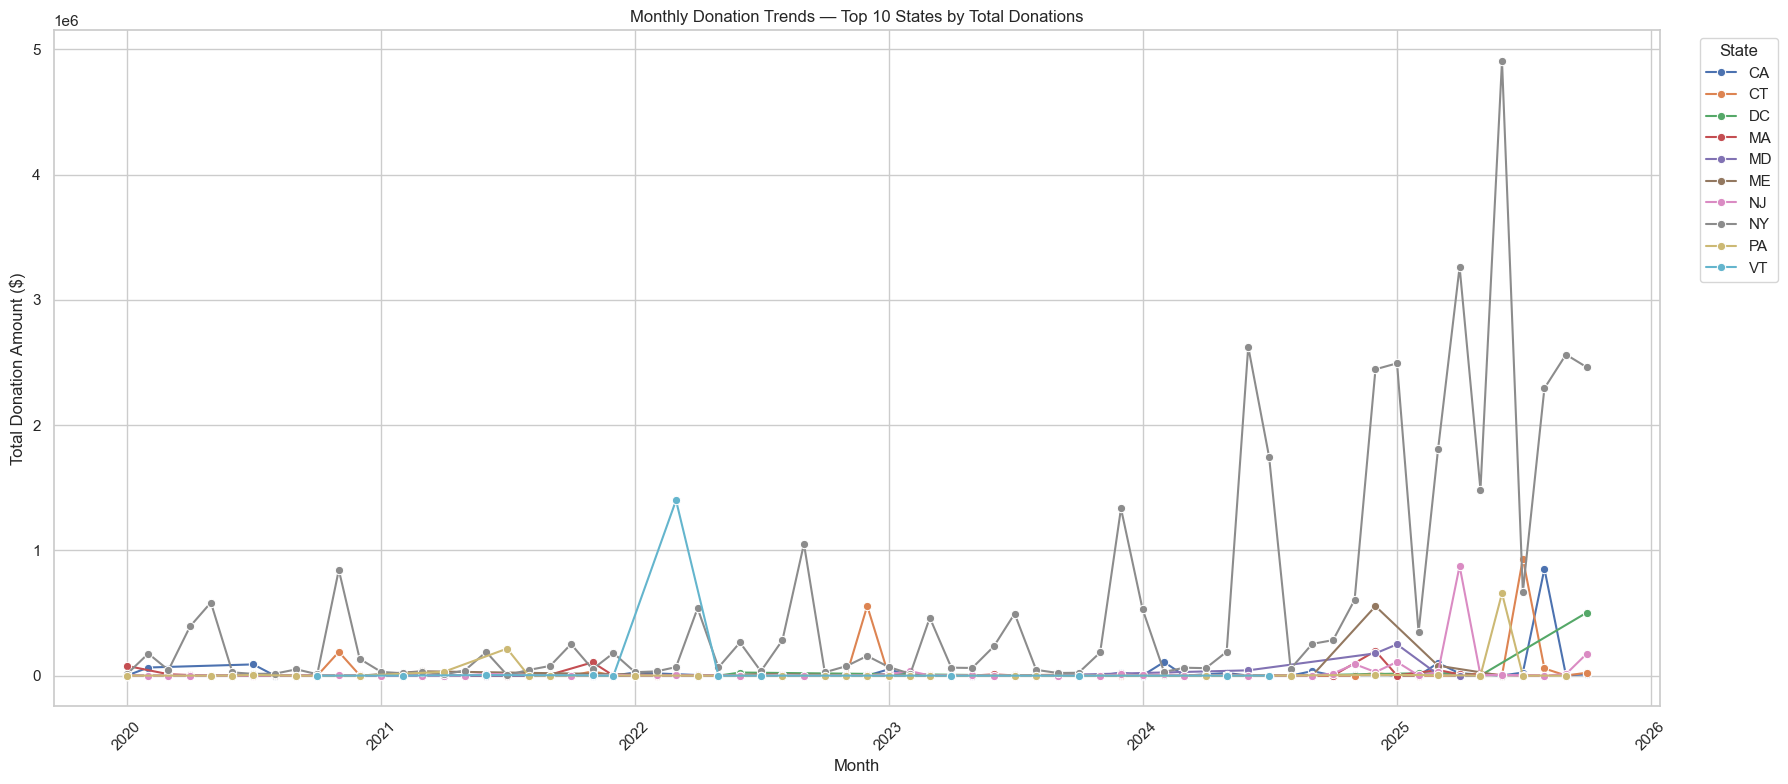

In [8]:
# Per-state monthly trends for top 10 states by total donations
state_totals = (
    donor_master.dropna(subset=["State", "Donation Amount"]) 
    .groupby("State", as_index=False)["Donation Amount"]
    .sum()
    .sort_values("Donation Amount", ascending=False)
)

top_states = state_totals.head(10)["State"].tolist()
state_time = time_df[time_df["State"].isin(top_states)].copy()

state_monthly = (
    state_time.groupby(["State", "Month"], as_index=False)["Donation Amount"]
    .sum()
    .sort_values(["State", "Month"])
)

plt.figure(figsize=(18, 8))
sns.lineplot(data=state_monthly, x="Month", y="Donation Amount", hue="State", marker="o")
plt.xlabel("Month")
plt.ylabel("Total Donation Amount ($)")
plt.title("Monthly Donation Trends — Top 10 States by Total Donations")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Observations (Top states over time)
Overlaying the top states makes it easy to compare whether trends are synchronized (shared seasonality) or state-specific (local events/outreach).